### /////////

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

In [2]:
# Axis 2 — MOFA multi-omic
MULTI_OMICS_BASE        = Path("/Users/bgadmin/Downloads/multiomics_preproc")
MULTI_OMICS_CLUSTER_DIR = MULTI_OMICS_BASE / "clustering_leiden_A"
MULTI_OMICS_VALID_DIR   = MULTI_OMICS_BASE / "validation"
MULTI_OMICS_SUBTYPE_DIR = MULTI_OMICS_BASE / "subtyping"

# Axis 1 — CNV only
CNV_ONLY_BASE   = Path("/Users/bgadmin/Downloads/cnv_preproc_release_v2")
CNV_ONLY_LEIDEN = CNV_ONLY_BASE / "subtyping_leiden_A"
CNV_ONLY_SIG2_DIR = CNV_ONLY_LEIDEN / "signatures_two_view"

# Output directory
OUT_DIR = MULTI_OMICS_BASE / "comparison_axe1_vs_axe2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ── Mapping V4 : CNV roots (codes courts) → groupes multi-omics (noms longs) ──
# Source : leiden_manifest_stats.tsv des deux pipelines — 34 paires
# Groupes CNV sans contrepartie multi-omics (résiduels sous seuil 50) non inclus :
#   C16, C30_C39, C40_C41_C48, C49, C60_C63, C64_C68, C73_C75, C80

cnv_to_mofa = {
    # Head & Neck — séparés par tissu (V3)
    "C00_C06"                  : "Oral_cavity (C00-C06)",
    "C07_C14"                  : "Pharynx (C07-C14)",
    # Esophagus — séparés par morphologie (V2)
    "C15_SCC"                  : "Esophagus_SCC (C15)",
    "C15_ADENO"                : "Esophagus_ADENO (C15)",
    # C16 — séparés par histologie (V4)
    "C16_Adenocarcinoma"       : "C16_Adenocarcinoma",
    "C16_Carcinoma_other"      : "C16_Carcinoma_other",
    # Colorectal / Liver / Pancreas
    "C18_C20"                  : "Colorectal (C18-C20)",
    "C22_C24"                  : "Liver/Biliary (C22-C24)",
    "C25"                      : "C25",
    # Lung — séparés par histologie (V4)
    "C30_C39_Adenocarcinoma"   : "Lung_Adenocarcinoma",
    "C30_C39_Carcinoma_other"  : "Lung_Carcinoma_other",
    "C30_C39_Mesothelioma"     : "Lung_Mesothelioma",
    "C30_C39_Other_rare"       : "Lung_Other_rare",
    "C30_C39_SCC"              : "Lung_SCC",
    # Bone/SoftTissue — séparés par histologie (V4)
    "C40_C41_C48_Sarcoma"      : "Bone/SoftTissue_Sarcoma",
    # Blood/Lymph / Skin
    "C42"                      : "Blood/Lymph (C42)",
    "C44"                      : "Skin (C44)",
    # SoftTissue — séparés par histologie (V4)
    "C49_Melanoma"             : "SoftTissue_Melanoma",
    "C49_Sarcoma"              : "SoftTissue_Sarcoma",
    # Breast
    "C50"                      : "Breast (C50)",
    # Gynecologic — résiduel + séparés par histologie (V4)
    "C51_C58"                  : "Gynecologic (C51-C58)",
    "C51_C58_Adenocarcinoma"   : "Gynecologic_Adenocarcinoma",
    "C51_C58_SCC"              : "Gynecologic_SCC",
    # Male genital — séparés par histologie (V4)
    "C60_C63_Adenocarcinoma"   : "Male genital_Adenocarcinoma",
    "C60_C63_Carcinoma_other"  : "Male genital_Carcinoma_other",
    "C60_C63_Germ_cell_tumor"  : "Male genital_Germ_cell_tumor",
    # Urinary — séparés par histologie (V4)
    "C64_C68_Adenocarcinoma"   : "Urinary_Adenocarcinoma",
    "C64_C68_Carcinoma_other"  : "Urinary_Carcinoma_other",
    # Eye/CNS / Brain
    "C69_C70_C72"              : "Eye/CNS (C69-C72)",
    "C71"                      : "Brain (C71)",
    # Thyroid/Endocrine — séparés par histologie (V4)
    "C73_C75_Adenocarcinoma"   : "Thyroid/Endocrine_Adenocarcinoma",
    "C73_C75_Carcinoma_other"  : "Thyroid/Endocrine_Carcinoma_other",
    "C73_C75_Other_rare"       : "Thyroid/Endocrine_Other_rare",
    # Lymph nodes
    "C77"                      : "Lymph nodes (C77)",
}

# ── Filenames dans clusters_by_group/ du pipeline multi-omics ──
mofa_group_to_file = {
    "Oral_cavity (C00-C06)"             : "Oral_cavity_C00-C06_clusters_leiden_cpm.parquet",
    "Pharynx (C07-C14)"                 : "Pharynx_C07-C14_clusters_leiden_cpm.parquet",
    "Esophagus_SCC (C15)"               : "Esophagus_SCC_C15_clusters_leiden_cpm.parquet",
    "Esophagus_ADENO (C15)"             : "Esophagus_ADENO_C15_clusters_leiden_cpm.parquet",
    "C16_Adenocarcinoma"                : "C16_Adenocarcinoma_clusters_leiden_cpm.parquet",
    "C16_Carcinoma_other"               : "C16_Carcinoma_other_clusters_leiden_cpm.parquet",
    "Colorectal (C18-C20)"              : "Colorectal_C18-C20_clusters_leiden_cpm.parquet",
    "Liver/Biliary (C22-C24)"           : "Liver_Biliary_C22-C24_clusters_leiden_cpm.parquet",
    "C25"                               : "C25_clusters_leiden_cpm.parquet",
    "Lung_Adenocarcinoma"               : "Lung_Adenocarcinoma_clusters_leiden_cpm.parquet",
    "Lung_Carcinoma_other"              : "Lung_Carcinoma_other_clusters_leiden_cpm.parquet",
    "Lung_Mesothelioma"                 : "Lung_Mesothelioma_clusters_leiden_cpm.parquet",
    "Lung_Other_rare"                   : "Lung_Other_rare_clusters_leiden_cpm.parquet",
    "Lung_SCC"                          : "Lung_SCC_clusters_leiden_cpm.parquet",
    "Bone/SoftTissue_Sarcoma"           : "Bone_SoftTissue_Sarcoma_clusters_leiden_cpm.parquet",
    "Blood/Lymph (C42)"                 : "Blood_Lymph_C42_clusters_leiden_cpm.parquet",
    "Skin (C44)"                        : "Skin_C44_clusters_leiden_cpm.parquet",
    "SoftTissue_Melanoma"               : "SoftTissue_Melanoma_clusters_leiden_cpm.parquet",
    "SoftTissue_Sarcoma"                : "SoftTissue_Sarcoma_clusters_leiden_cpm.parquet",
    "Breast (C50)"                      : "Breast_C50_clusters_leiden_cpm.parquet",
    "Gynecologic (C51-C58)"             : "Gynecologic_C51-C58_clusters_leiden_cpm.parquet",
    "Gynecologic_Adenocarcinoma"        : "Gynecologic_Adenocarcinoma_clusters_leiden_cpm.parquet",
    "Gynecologic_SCC"                   : "Gynecologic_SCC_clusters_leiden_cpm.parquet",
    "Male genital_Adenocarcinoma"       : "Male_genital_Adenocarcinoma_clusters_leiden_cpm.parquet",
    "Male genital_Carcinoma_other"      : "Male_genital_Carcinoma_other_clusters_leiden_cpm.parquet",
    "Male genital_Germ_cell_tumor"      : "Male_genital_Germ_cell_tumor_clusters_leiden_cpm.parquet",
    "Urinary_Adenocarcinoma"            : "Urinary_Adenocarcinoma_clusters_leiden_cpm.parquet",
    "Urinary_Carcinoma_other"           : "Urinary_Carcinoma_other_clusters_leiden_cpm.parquet",
    "Eye/CNS (C69-C72)"                 : "Eye_CNS_C69-C72_clusters_leiden_cpm.parquet",
    "Brain (C71)"                       : "Brain_C71_clusters_leiden_cpm.parquet",
    "Thyroid/Endocrine_Adenocarcinoma"  : "Thyroid_Endocrine_Adenocarcinoma_clusters_leiden_cpm.parquet",
    "Thyroid/Endocrine_Carcinoma_other" : "Thyroid_Endocrine_Carcinoma_other_clusters_leiden_cpm.parquet",
    "Thyroid/Endocrine_Other_rare"      : "Thyroid_Endocrine_Other_rare_clusters_leiden_cpm.parquet",
    "Lymph nodes (C77)"                 : "Lymph_nodes_C77_clusters_leiden_cpm.parquet",
}

# ── Vérification ──
mofa_leiden_check = pd.read_csv(
    MULTI_OMICS_CLUSTER_DIR / "leiden_manifest_stats.tsv", sep="\t"
)
mofa_available = set(mofa_leiden_check["cancer_group"].unique())
missing_mofa  = set(cnv_to_mofa.values()) - mofa_available
missing_files = {g: f for g, f in mofa_group_to_file.items()
                 if not (MULTI_OMICS_CLUSTER_DIR / "clusters_by_group" / f).exists()}

print(f"Mapping V4 : {len(cnv_to_mofa)} paires CNV → multi-omics")
if missing_mofa:
    print(f"  WARN groupes absents du manifest MOFA : {missing_mofa}")
else:
    print("  Tous les groupes MOFA présents dans le manifest ✓")
if missing_files:
    print(f"  WARN fichiers manquants : {missing_files}")
else:
    print("  Tous les fichiers clusters_by_group présents ✓")


Mapping V4 : 34 paires CNV → multi-omics
  Tous les groupes MOFA présents dans le manifest ✓
  Tous les fichiers clusters_by_group présents ✓


In [4]:
# Load all source files 

# Axis① — CNV only
cnv_leiden = pd.read_csv(
    CNV_ONLY_BASE / "subtyping_leiden_A/leiden_manifest_stats.tsv",
    sep="\t"
)
cnv_purity = pd.read_csv(
    CNV_ONLY_BASE / "final_space/knn_index/cnv_purity_per_group.tsv",
    sep="\t"
)
cnv_pred = pd.read_csv(
    CNV_ONLY_SIG2_DIR / "prediction_validation/prediction_manifest.tsv",
    sep="\t"
)
cnv_trust = pd.read_csv(
    CNV_ONLY_SIG2_DIR / "prediction_validation/trust_manifest.tsv",
    sep="\t"
)
cnv_sig = pd.read_csv(
    CNV_ONLY_SIG2_DIR / "two_view_signature_manifest.tsv",
    sep="\t"
)

# Axis② — MOFA
mofa_leiden = pd.read_csv(
    MULTI_OMICS_CLUSTER_DIR / "leiden_manifest_stats.tsv",
    sep="\t"
)
mofa_purity = pd.read_csv(
    MULTI_OMICS_BASE / "knn_index/mofa_purity_per_group.tsv",
    sep="\t"
)
mofa_pred = pd.read_csv(
    MULTI_OMICS_VALID_DIR / "cluster_predictability.tsv",
    sep="\t"
)
mofa_morph = pd.read_csv(
    MULTI_OMICS_VALID_DIR / "morphology_association.tsv",
    sep="\t"
)
mofa_qc = pd.read_csv(
    MULTI_OMICS_SUBTYPE_DIR / "subtyping_qc.tsv",
    sep="\t"
)
mofa_sig_df = pd.read_csv(
    MULTI_OMICS_SUBTYPE_DIR / "mofa_signatures.tsv",
    sep="\t"
)

# Quick shape check
for name, df in [
    ("cnv_leiden",  cnv_leiden),
    ("cnv_purity",  cnv_purity),
    ("cnv_pred",    cnv_pred),
    ("cnv_trust",   cnv_trust),
    ("cnv_sig",     cnv_sig),
    ("mofa_leiden", mofa_leiden),
    ("mofa_purity", mofa_purity),
    ("mofa_pred",   mofa_pred),
    ("mofa_morph",  mofa_morph),
    ("mofa_qc",     mofa_qc),
]:
    key_col = next(
        (c for c in df.columns if c in ["root", "cancer_group"]),
        df.columns[0]
    )
    print(f"{name:15s} : {df.shape[0]:3d} rows | "
          f"unique groups : {df[key_col].nunique()}")

cnv_leiden      :  35 rows | unique groups : 35
cnv_purity      :  35 rows | unique groups : 35
cnv_pred        :  42 rows | unique groups : 14
cnv_trust       :  42 rows | unique groups : 42
cnv_sig         :  42 rows | unique groups : 42
mofa_leiden     :  34 rows | unique groups : 34
mofa_purity     :  46 rows | unique groups : 46
mofa_pred       :  11 rows | unique groups : 11
mofa_morph      :  11 rows | unique groups : 11
mofa_qc         :  34 rows | unique groups : 34


In [5]:
# Build comparison table 

#  Axis① preparation 

# Leiden stats
cnv_base = (
    cnv_leiden[["root", "n_vertices",
                "n_clusters_final_excl_outliers", "n_outliers"]]
    .rename(columns={
        "n_vertices":                     "n_samples_cnv",
        "n_clusters_final_excl_outliers": "n_clusters_cnv",
        "n_outliers":                     "n_outliers_cnv",
    })
    .copy()
)
cnv_base["cancer_group"] = cnv_base["root"].map(cnv_to_mofa)
cnv_base = cnv_base.dropna(subset=["cancer_group"])  # excludes C80

# Best prediction model per root
cnv_pred_best = (
    cnv_pred[cnv_pred["status"] == "ok"]
    .sort_values("macro_f1", ascending=False)
    .groupby("root", as_index=False).first()
    [["root", "balanced_acc", "macro_f1"]]
    .rename(columns={"balanced_acc": "bal_acc_cnv", "macro_f1": "f1_cnv"})
)

# Platform trust
cnv_trust_info = (
    cnv_trust[["root", "n_clusters",
               "A1_cramersV_cluster_platform",
               "A2_platform_macro_f1_from_features"]]
    .rename(columns={
        "n_clusters":                         "n_clusters_trust_cnv",
        "A1_cramersV_cluster_platform":       "cramersV_platform_cnv",
        "A2_platform_macro_f1_from_features": "plat_f1_cnv",
    })
)

# Signatures
cnv_sig_info = (
    cnv_sig[["root", "n_clusters_kept",
             "track2_rows_signature_top", "warn_track2_empty"]]
    .rename(columns={
        "n_clusters_kept":           "n_clusters_with_sig_cnv",
        "track2_rows_signature_top": "n_track2_markers_cnv",
    })
)

# kNN purity
cnv_purity_info = (
    cnv_purity[["root", "purity_topo", "purity_morpho", "purity_combined"]]
    .rename(columns={
        "purity_topo":     "knn_purity_topo_cnv",
        "purity_morpho":   "knn_purity_morpho_cnv",
        "purity_combined": "knn_purity_combined_cnv",
    })
)

# Merge Axis①
cnv_full = (
    cnv_base
    .merge(cnv_pred_best,   on="root", how="left")
    .merge(cnv_trust_info,  on="root", how="left")
    .merge(cnv_sig_info,    on="root", how="left")
    .merge(cnv_purity_info, on="root", how="left")
)

# --- Axis② preparation ---

# Leiden stats
mofa_base = (
    mofa_leiden[["cancer_group", "n_vertices",
                 "n_clusters_final_excl_outliers", "n_outliers"]]
    .rename(columns={
        "n_vertices":                     "n_samples_mofa",
        "n_clusters_final_excl_outliers": "n_clusters_mofa",
        "n_outliers":                     "n_outliers_mofa",
    })
    .copy()
)

# Prediction
mofa_pred_info = (
    mofa_pred[["cancer_group", "bal_acc_mean", "bal_acc_std", "f1_macro_mean"]]
    .rename(columns={
        "bal_acc_mean":  "bal_acc_mofa",
        "bal_acc_std":   "bal_acc_std_mofa",
        "f1_macro_mean": "f1_mofa",
    })
)

# Morphology association
mofa_morph_info = (
    mofa_morph[["cancer_group", "cramersV_morph", "p_value"]]
    .rename(columns={
        "cramersV_morph": "cramersV_morph_mofa",
        "p_value":        "p_morph_mofa",
    })
)

# QC
mofa_qc_info = (
    mofa_qc[["cancer_group", "morph_topfrac_weighted", "frac_outliers"]]
    .rename(columns={
        "morph_topfrac_weighted": "morph_topfrac_mofa",
        "frac_outliers":          "frac_outliers_mofa",
    })
)

# kNN purity — restrict to the 19 mapped groups
mofa_purity_info = (
    mofa_purity[mofa_purity["cancer_group"].isin(set(cnv_to_mofa.values()))]
    [["cancer_group", "purity_topo", "purity_morpho", "purity_combined"]]
    .rename(columns={
        "purity_topo":     "knn_purity_topo_mofa",
        "purity_morpho":   "knn_purity_morpho_mofa",
        "purity_combined": "knn_purity_combined_mofa",
    })
)

# Merge Axis②
mofa_full = (
    mofa_base
    .merge(mofa_pred_info,   on="cancer_group", how="left")
    .merge(mofa_morph_info,  on="cancer_group", how="left")
    .merge(mofa_qc_info,     on="cancer_group", how="left")
    .merge(mofa_purity_info, on="cancer_group", how="left")
)

# --- Final merge ---
comparison_df = cnv_full.merge(mofa_full, on="cancer_group", how="inner")

# Deltas
comparison_df["delta_knn_purity_topo"]   = (
    comparison_df["knn_purity_topo_mofa"]   - comparison_df["knn_purity_topo_cnv"]
)
comparison_df["delta_knn_purity_morpho"] = (
    comparison_df["knn_purity_morpho_mofa"] - comparison_df["knn_purity_morpho_cnv"]
)
comparison_df["frac_outliers_cnv"] = (
    comparison_df["n_outliers_cnv"] /
    comparison_df["n_samples_cnv"].clip(lower=1)
)

comparison_df = comparison_df.sort_values(
    "delta_knn_purity_morpho", ascending=False
).reset_index(drop=True)

print(f"comparison_df : {comparison_df.shape}")
print(f"Groups : {comparison_df['cancer_group'].tolist()}")

comparison_df : (34, 32)
Groups : ['Blood/Lymph (C42)', 'Brain (C71)', 'Male genital_Germ_cell_tumor', 'Lung_Other_rare', 'Urinary_Adenocarcinoma', 'Gynecologic_Adenocarcinoma', 'Skin (C44)', 'Oral_cavity (C00-C06)', 'SoftTissue_Sarcoma', 'Liver/Biliary (C22-C24)', 'C16_Adenocarcinoma', 'Colorectal (C18-C20)', 'Eye/CNS (C69-C72)', 'Thyroid/Endocrine_Other_rare', 'Gynecologic_SCC', 'Lymph nodes (C77)', 'Gynecologic (C51-C58)', 'Breast (C50)', 'Pharynx (C07-C14)', 'Esophagus_SCC (C15)', 'Thyroid/Endocrine_Carcinoma_other', 'Bone/SoftTissue_Sarcoma', 'SoftTissue_Melanoma', 'Lung_SCC', 'Lung_Carcinoma_other', 'Thyroid/Endocrine_Adenocarcinoma', 'Lung_Adenocarcinoma', 'Male genital_Adenocarcinoma', 'Male genital_Carcinoma_other', 'C25', 'Esophagus_ADENO (C15)', 'Urinary_Carcinoma_other', 'Lung_Mesothelioma', 'C16_Carcinoma_other']


In [6]:
# MOFA discriminant omics per group 
# For each group, identify which omics drive the MOFA factors
# that significantly discriminate between clusters (q ≤ 0.05,
# |AUC − 0.5| ≥ 0.1)
omic_summary_rows = []

for cancer_group in comparison_df["cancer_group"].tolist():
    sub = mofa_sig_df[
        (mofa_sig_df["cancer_group"] == cancer_group) &
        (mofa_sig_df["q_value"] <= 0.05) &
        (np.abs(mofa_sig_df["auc"] - 0.5) >= 0.1)
    ].copy()

    if sub.empty:
        omic_summary_rows.append({
            "cancer_group":  cancer_group,
            "n_sig_factors": 0,
            "dominant_omic": "none",
            "omic_breakdown": "",
        })
        continue

    omic_vc = sub["dominant_omic"].value_counts()
    omic_summary_rows.append({
        "cancer_group":   cancer_group,
        "n_sig_factors":  int(sub["factor"].nunique()),
        "dominant_omic":  str(omic_vc.index[0]),
        "omic_breakdown": " / ".join([f"{o}:{n}" for o, n in omic_vc.items()]),
    })

omic_summary_df = pd.DataFrame(omic_summary_rows)
comparison_df = comparison_df.merge(omic_summary_df, on="cancer_group", how="left")

print("Discriminant omics per group ")
print(omic_summary_df.to_string(index=False))

Discriminant omics per group 
                     cancer_group  n_sig_factors dominant_omic            omic_breakdown
                Blood/Lymph (C42)              0          none                          
                      Brain (C71)             20          Meth Meth:25 / RNA:12 / CNV:11
     Male genital_Germ_cell_tumor              0          none                          
                  Lung_Other_rare              0          none                          
           Urinary_Adenocarcinoma             19          Meth  Meth:22 / RNA:11 / CNV:8
       Gynecologic_Adenocarcinoma             20          Meth  Meth:33 / RNA:13 / CNV:7
                       Skin (C44)              0          none                          
            Oral_cavity (C00-C06)              0          none                          
               SoftTissue_Sarcoma              0          none                          
          Liver/Biliary (C22-C24)             12          Meth   Meth:14 / CNV:6

In [7]:
# Table check 

cols_check = [
    "cancer_group", "n_samples_cnv", "n_samples_mofa",
    "n_clusters_cnv", "n_clusters_mofa",
    "knn_purity_morpho_cnv", "knn_purity_morpho_mofa",
    "delta_knn_purity_morpho",
]

print("Comparison table (sorted by delta kNN purity morpho)\n")
print(comparison_df[cols_check].round(3).to_string(index=False))

print("\nNaN per column ")
nan_counts = comparison_df[cols_check].isna().sum()
print(nan_counts[nan_counts > 0].to_string() or "No NaN ✓")

print("\n n_samples symmetry check")
asym = comparison_df[comparison_df["n_samples_cnv"] != comparison_df["n_samples_mofa"]]
if asym.empty:
    print("All groups have identical sample counts ✓")
else:
    print(asym[["cancer_group", "n_samples_cnv", "n_samples_mofa"]].to_string(index=False))

Comparison table (sorted by delta kNN purity morpho)

                     cancer_group  n_samples_cnv  n_samples_mofa  n_clusters_cnv  n_clusters_mofa  knn_purity_morpho_cnv  knn_purity_morpho_mofa  delta_knn_purity_morpho
                Blood/Lymph (C42)            107             107               1                1                  0.513                   0.960                    0.447
                      Brain (C71)            737             737               2                3                  0.333                   0.426                    0.093
     Male genital_Germ_cell_tumor             96              96               1                1                  0.559                   0.594                    0.035
                  Lung_Other_rare            106             108               1                1                  0.164                   0.161                   -0.003
           Urinary_Adenocarcinoma            632             632               2                

In [9]:
# ── Sample count asymmetry diagnostic (V4) ──────────────────────────
#
# Depuis la V4, "Urinary (C64-C68)" a été scindé par histologie en
# Urinary_Adenocarcinoma / Urinary_Carcinoma_other. On détecte
# dynamiquement les groupes urinary présents dans comparison_df
# plutôt que de hardcoder l'ancien nom V3.

urinary_groups = [
    g for g in comparison_df["cancer_group"].unique()
    if g.lower().startswith("urinary")
]

if not urinary_groups:
    print("Aucun groupe 'Urinary' trouvé dans comparison_df.")
    print("Groupes disponibles :", sorted(comparison_df["cancer_group"].unique()))
else:
    print(f"Groupes Urinary détectés : {urinary_groups}\n")

    mofa_to_cnv_root = {v: k for k, v in cnv_to_mofa.items()}

    for URINARY_GROUP in urinary_groups:
        URINARY_ROOT = mofa_to_cnv_root.get(URINARY_GROUP)
        if URINARY_ROOT is None:
            print(f"[SKIP] pas de root CNV mappé pour {URINARY_GROUP}")
            continue

        cnv_meta_path = CNV_ONLY_BASE / "final_space/meta_final" / f"{URINARY_ROOT}_meta_final.tsv"
        if not cnv_meta_path.exists():
            print(f"[SKIP] fichier meta CNV manquant pour {URINARY_ROOT} : {cnv_meta_path}")
            continue

        meta_final_df = pd.read_csv(MULTI_OMICS_BASE / "meta_final.tsv", sep="\t", dtype=str)
        cnv_meta_df = pd.read_csv(cnv_meta_path, sep="\t", dtype=str)

        ids_mofa_urinary = set(
            meta_final_df[meta_final_df["cancer_group"] == URINARY_GROUP]["biosample_id"]
        )
        ids_cnv_urinary = set(cnv_meta_df["biosample_id"])
        extra_in_mofa = ids_mofa_urinary - ids_cnv_urinary

        mofa_purity_sample = pd.read_csv(
            MULTI_OMICS_BASE / "knn_index" / "mofa_purity_per_sample.tsv",
            sep="\t", dtype={"biosample_id": str}
        )

        purity_extra = mofa_purity_sample[
            mofa_purity_sample["biosample_id"].isin(extra_in_mofa)
        ]["purity_morpho"]
        purity_common = mofa_purity_sample[
            mofa_purity_sample["biosample_id"].isin(ids_mofa_urinary & ids_cnv_urinary)
        ]["purity_morpho"]

        purity_mofa_observed = mofa_purity_sample[
            mofa_purity_sample["biosample_id"].isin(ids_mofa_urinary)
        ]["purity_morpho"].mean()
        purity_mofa_corrected = purity_common.mean()

        row_match = comparison_df[comparison_df["cancer_group"] == URINARY_GROUP]
        if row_match.empty:
            print(f"[SKIP] {URINARY_GROUP} absent de comparison_df")
            continue
        purity_cnv_urinary = row_match["knn_purity_morpho_cnv"].values[0]

        print(f"=== {URINARY_GROUP} (root CNV: {URINARY_ROOT}) ===")
        print(f"Samples MOFA         : {len(ids_mofa_urinary)}")
        print(f"Samples CNV only     : {len(ids_cnv_urinary)}")
        print(f"Common               : {len(ids_mofa_urinary & ids_cnv_urinary)}")
        print(f"Extra dans MOFA      : {len(extra_in_mofa)}")
        if len(purity_extra) > 0:
            print(f"  Extra samples purity : mean={purity_extra.mean():.3f}  n={len(purity_extra)}")
        print(f"  Common samples purity: mean={purity_common.mean():.3f}  n={len(purity_common)}")
        print(f"Purity CNV only      : {purity_cnv_urinary:.3f}")
        print(f"Purity MOFA observed : {purity_mofa_observed:.3f}")
        print(f"Purity MOFA corrected: {purity_mofa_corrected:.3f}")
        print(f"Delta observed       : {purity_mofa_observed  - purity_cnv_urinary:+.3f}")
        print(f"Delta corrected      : {purity_mofa_corrected - purity_cnv_urinary:+.3f}\n")

Groupes Urinary détectés : ['Urinary_Adenocarcinoma', 'Urinary_Carcinoma_other']

=== Urinary_Adenocarcinoma (root CNV: C64_C68_Adenocarcinoma) ===
Samples MOFA         : 632
Samples CNV only     : 632
Common               : 632
Extra dans MOFA      : 0
  Common samples purity: mean=0.704  n=632
Purity CNV only      : 0.755
Purity MOFA observed : 0.704
Purity MOFA corrected: 0.704
Delta observed       : -0.051
Delta corrected      : -0.051

=== Urinary_Carcinoma_other (root CNV: C64_C68_Carcinoma_other) ===
Samples MOFA         : 476
Samples CNV only     : 476
Common               : 476
Extra dans MOFA      : 0
  Common samples purity: mean=0.265  n=476
Purity CNV only      : 0.704
Purity MOFA observed : 0.265
Purity MOFA corrected: 0.265
Delta observed       : -0.439
Delta corrected      : -0.439



In [10]:
# ARI vs morphology 
# ARI measures global cluster-to-morphology alignment.
# It is invariant to the number of clusters, directly correcting
# the granularity bias (n_clusters_cnv ≠ n_clusters_mofa).
# Both axes are evaluated against the same reference labels
# (icdo_morphology_id), making the comparison fair.

CLUSTER_DIR_MOFA = MULTI_OMICS_CLUSTER_DIR / "clusters_by_group"
CLUSTER_DIR_CNV  = CNV_ONLY_LEIDEN / "clusters_by_root"

cnv_root_to_file = {
    root: f"{root}_clusters_leiden_cpm.parquet"
    for root in cnv_to_mofa.keys()
}

meta_ref = pd.read_csv(
    MULTI_OMICS_BASE / "meta_final.tsv",
    sep="\t",
    usecols=["biosample_id", "cancer_group", "icdo_morphology_id"],
    dtype=str
)

ari_rows = []

for cnv_root, mofa_group in cnv_to_mofa.items():
    mofa_file = CLUSTER_DIR_MOFA / mofa_group_to_file[mofa_group]
    cnv_file  = CLUSTER_DIR_CNV  / cnv_root_to_file[cnv_root]

    if not mofa_file.exists() or not cnv_file.exists():
        print(f"[MISSING] {mofa_group}")
        ari_rows.append({
            "cancer_group": mofa_group,
            "ari_cnv": np.nan, "ari_mofa": np.nan,
            "delta_ari": np.nan, "n_common": 0,
        })
        continue

    mofa_clusters = pd.read_parquet(mofa_file)[["biosample_id", "cluster"]]
    cnv_clusters  = pd.read_parquet(cnv_file) [["biosample_id", "cluster"]]
    morpho        = meta_ref[meta_ref["cancer_group"] == mofa_group][
                        ["biosample_id", "icdo_morphology_id"]
                    ]

    common_ids = (
        set(mofa_clusters["biosample_id"])
        & set(cnv_clusters["biosample_id"])
        & set(morpho["biosample_id"])
    )

    if len(common_ids) < 30:
        print(f"[TOO SMALL] {mofa_group} — n={len(common_ids)}")
        ari_rows.append({
            "cancer_group": mofa_group,
            "ari_cnv": np.nan, "ari_mofa": np.nan,
            "delta_ari": np.nan, "n_common": len(common_ids),
        })
        continue

    ids_list = sorted(common_ids)
    morpho_labels = (
        morpho.set_index("biosample_id")
              .reindex(ids_list)["icdo_morphology_id"]
              .fillna("unknown").values
    )
    cnv_labels = (
        cnv_clusters.set_index("biosample_id")
                    .reindex(ids_list)["cluster"]
                    .fillna(-1).astype(str).values
    )
    mofa_labels = (
        mofa_clusters.set_index("biosample_id")
                     .reindex(ids_list)["cluster"]
                     .fillna(-1).astype(str).values
    )

    ari_cnv  = adjusted_rand_score(morpho_labels, cnv_labels)
    ari_mofa = adjusted_rand_score(morpho_labels, mofa_labels)

    ari_rows.append({
        "cancer_group": mofa_group,
        "ari_cnv":      round(ari_cnv,  4),
        "ari_mofa":     round(ari_mofa, 4),
        "delta_ari":    round(ari_mofa - ari_cnv, 4),
        "n_common":     len(common_ids),
    })
    print(f"[OK] {mofa_group:40s} "
          f"ARI_cnv={ari_cnv:.3f}  ARI_mofa={ari_mofa:.3f}  "
          f"delta={ari_mofa - ari_cnv:+.3f}  n={len(common_ids)}")

ari_df = pd.DataFrame(ari_rows).sort_values("delta_ari", ascending=False)
print("\n ARI vs morphology — CNV only vs MOFA \n")
print(ari_df.round(4).to_string(index=False))

comparison_df = comparison_df.merge(
    ari_df[["cancer_group", "ari_cnv", "ari_mofa", "delta_ari"]],
    on="cancer_group", how="left"
)

[OK] Oral_cavity (C00-C06)                    ARI_cnv=0.034  ARI_mofa=0.000  delta=-0.034  n=257
[OK] Pharynx (C07-C14)                        ARI_cnv=0.000  ARI_mofa=0.000  delta=+0.000  n=122
[OK] Esophagus_SCC (C15)                      ARI_cnv=-0.017  ARI_mofa=0.000  delta=+0.017  n=93
[OK] Esophagus_ADENO (C15)                    ARI_cnv=1.000  ARI_mofa=1.000  delta=+0.000  n=85
[OK] C16_Adenocarcinoma                       ARI_cnv=0.004  ARI_mofa=-0.003  delta=-0.006  n=300
[OK] C16_Carcinoma_other                      ARI_cnv=0.000  ARI_mofa=0.000  delta=+0.000  n=76
[OK] Colorectal (C18-C20)                     ARI_cnv=0.159  ARI_mofa=-0.012  delta=-0.171  n=565
[OK] Liver/Biliary (C22-C24)                  ARI_cnv=0.028  ARI_mofa=-0.035  delta=-0.063  n=398
[OK] C25                                      ARI_cnv=0.000  ARI_mofa=0.086  delta=+0.086  n=165
[OK] Lung_Adenocarcinoma                      ARI_cnv=-0.029  ARI_mofa=0.028  delta=+0.057  n=451
[OK] Lung_Carcinoma_other   

In [11]:
#  Metric agreement + final classification 
# Two metrics are compared:
#   kNN purity  : local neighborhood coherence
#   ARI         : global cluster-morphology alignment (cluster-count invariant)
# Divergence between the two is itself informative.

def reconcile(row):
    delta_knn = row["delta_knn_purity_morpho"]
    delta_ari = row["delta_ari"]
    if pd.isna(delta_knn) or pd.isna(delta_ari):
        return "Insufficient data"
    if (delta_knn >  0.02) and (delta_ari >  0.02): return "MOFA better — both metrics agree"
    if (delta_knn < -0.02) and (delta_ari < -0.02): return "CNV better — both metrics agree"
    if (delta_knn >  0.02) and (delta_ari < -0.02): return "Divergent — local MOFA / global CNV"
    if (delta_knn < -0.02) and (delta_ari >  0.02): return "Divergent — local CNV / global MOFA"
    return "Neutral — no clear winner"

comparison_df["metric_agreement"] = comparison_df.apply(reconcile, axis=1)

def classify_final(row):
    n         = row["n_samples_cnv"]
    agreement = row["metric_agreement"]
    delta_ari = row["delta_ari"]

    if n < 150:
        return "Too small — unreliable"
    if agreement == "MOFA better — both metrics agree":
        return "Multi-omic adds value"
    if agreement == "CNV better — both metrics agree":
        return "CNV sufficient"
    if "Divergent — local CNV / global MOFA" in agreement:
        if pd.notna(delta_ari) and delta_ari > 0.10:
            return "Multi-omic adds value — global structure only"
        return "Neutral — conflicting signals"
    if "Divergent — local MOFA / global CNV" in agreement:
        return "Neutral — conflicting signals"
    return "Neutral — no clear winner"

comparison_df["interpretation"] = comparison_df.apply(classify_final, axis=1)

print("=== Final classification ===\n")
print(comparison_df[["cancer_group", "delta_knn_purity_morpho",
                      "delta_ari", "metric_agreement", "interpretation"]]
      .sort_values("delta_knn_purity_morpho", ascending=False)
      .to_string(index=False))

print("\n=== Distribution ===")
print(comparison_df["interpretation"].value_counts().to_string())

=== Final classification ===

                     cancer_group  delta_knn_purity_morpho  delta_ari                    metric_agreement                                interpretation
                Blood/Lymph (C42)                 0.446542     1.0000    MOFA better — both metrics agree                        Too small — unreliable
                      Brain (C71)                 0.093028     0.0451    MOFA better — both metrics agree                         Multi-omic adds value
     Male genital_Germ_cell_tumor                 0.035250     0.0000           Neutral — no clear winner                        Too small — unreliable
                  Lung_Other_rare                -0.002585     0.0075           Neutral — no clear winner                        Too small — unreliable
           Urinary_Adenocarcinoma                -0.050747    -0.2515     CNV better — both metrics agree                                CNV sufficient
       Gynecologic_Adenocarcinoma                -0.052908

In [12]:
# ── Step 8 — Final enriched table ─────────────────────────────────

final_table = comparison_df[[
    "cancer_group",
    "n_samples_cnv",
    "n_clusters_cnv",       "n_clusters_mofa",
    "knn_purity_morpho_cnv","knn_purity_morpho_mofa",
    "delta_knn_purity_morpho",
    "ari_cnv",              "ari_mofa",       "delta_ari",
    "metric_agreement",
    "n_sig_factors",        "dominant_omic",  "omic_breakdown",
    "interpretation",
]].sort_values("delta_knn_purity_morpho", ascending=False).reset_index(drop=True)

print("=== FINAL TABLE ===\n")
print(final_table.round(3).to_string(index=False))

# Save
final_table.to_csv(OUT_DIR / "comparison_final_unified.tsv", sep="\t", index=False)
print(f"\n[saved] comparison_final_unified.tsv")

# ── Narrative summary ─────────────────────────────────────────────
narratives = {
    "Multi-omic adds value": (
        "CNV alone fails to capture the full biological heterogeneity. "
        "Methylation and/or RNA reveal additional subtype structure "
        "not visible in copy number profiles. These cancers show "
        "epigenetic or transcriptional heterogeneity independent of "
        "chromosomal instability."
    ),
    "Multi-omic adds value — global structure only": (
        "MOFA identifies biologically meaningful subtypes (high ARI) "
        "but the latent space is more diffuse locally (lower kNN purity). "
        "Multi-omics adds value for subtype discovery, but the integrated "
        "space is harder to navigate for similarity retrieval."
    ),
    "CNV sufficient": (
        "Copy number profiles alone provide strong morphological coherence. "
        "These cancers are typically driven by chromosomal instability — "
        "large-scale genomic alterations dominate the biological signal. "
        "Adding RNA or methylation does not improve cluster quality."
    ),
    "Neutral — conflicting signals": (
        "The two metrics disagree. Multi-omics may help for specific "
        "subtypes but not globally. Case-by-case investigation required."
    ),
    "Neutral — no clear winner": (
        "Neither axis shows a consistent advantage. The biological signal "
        "in CNV is already weak, and adding omics layers does not resolve "
        "the heterogeneity further."
    ),
    "Too small — unreliable": (
        "Insufficient sample size (n < 150). Excluded from interpretation."
    ),
}

print("\n" + "=" * 70)
print("NARRATIVE SUMMARY")
print("=" * 70)

for interp, explanation in narratives.items():
    sub = final_table[final_table["interpretation"] == interp]
    if sub.empty:
        continue
    print(f"\n{'─'*70}")
    print(f"[{interp}] — {len(sub)} group(s)")
    print(f"Why: {explanation}")
    print("Groups:")
    for _, row in sub.iterrows():
        print(f"  {row['cancer_group']:38s} "
              f"Δknn={row['delta_knn_purity_morpho']:+.3f}  "
              f"ΔARI={row['delta_ari']:+.3f}  "
              f"omics={row['omic_breakdown'] or '—'}")

print(f"\n{'='*70}")
print("BOTTOM LINE:")
print(f"  Multi-omics adds value : "
      f"{final_table['interpretation'].str.contains('Multi-omic').sum()} groups")
print(f"  CNV sufficient         : "
      f"{(final_table['interpretation'] == 'CNV sufficient').sum()} groups")
print(f"  Neutral / conflicting  : "
      f"{final_table['interpretation'].str.contains('Neutral').sum()} groups")
print(f"  Too small              : "
      f"{(final_table['interpretation'] == 'Too small — unreliable').sum()} groups")

=== FINAL TABLE ===

                     cancer_group  n_samples_cnv  n_clusters_cnv  n_clusters_mofa  knn_purity_morpho_cnv  knn_purity_morpho_mofa  delta_knn_purity_morpho  ari_cnv  ari_mofa  delta_ari                    metric_agreement  n_sig_factors dominant_omic            omic_breakdown                                interpretation
                Blood/Lymph (C42)            107               1                1                  0.513                   0.960                    0.447    0.000     1.000      1.000    MOFA better — both metrics agree              0          none                                                  Too small — unreliable
                      Brain (C71)            737               2                3                  0.333                   0.426                    0.093    0.109     0.154      0.045    MOFA better — both metrics agree             20          Meth Meth:25 / RNA:12 / CNV:11                         Multi-omic adds value
     Male genita

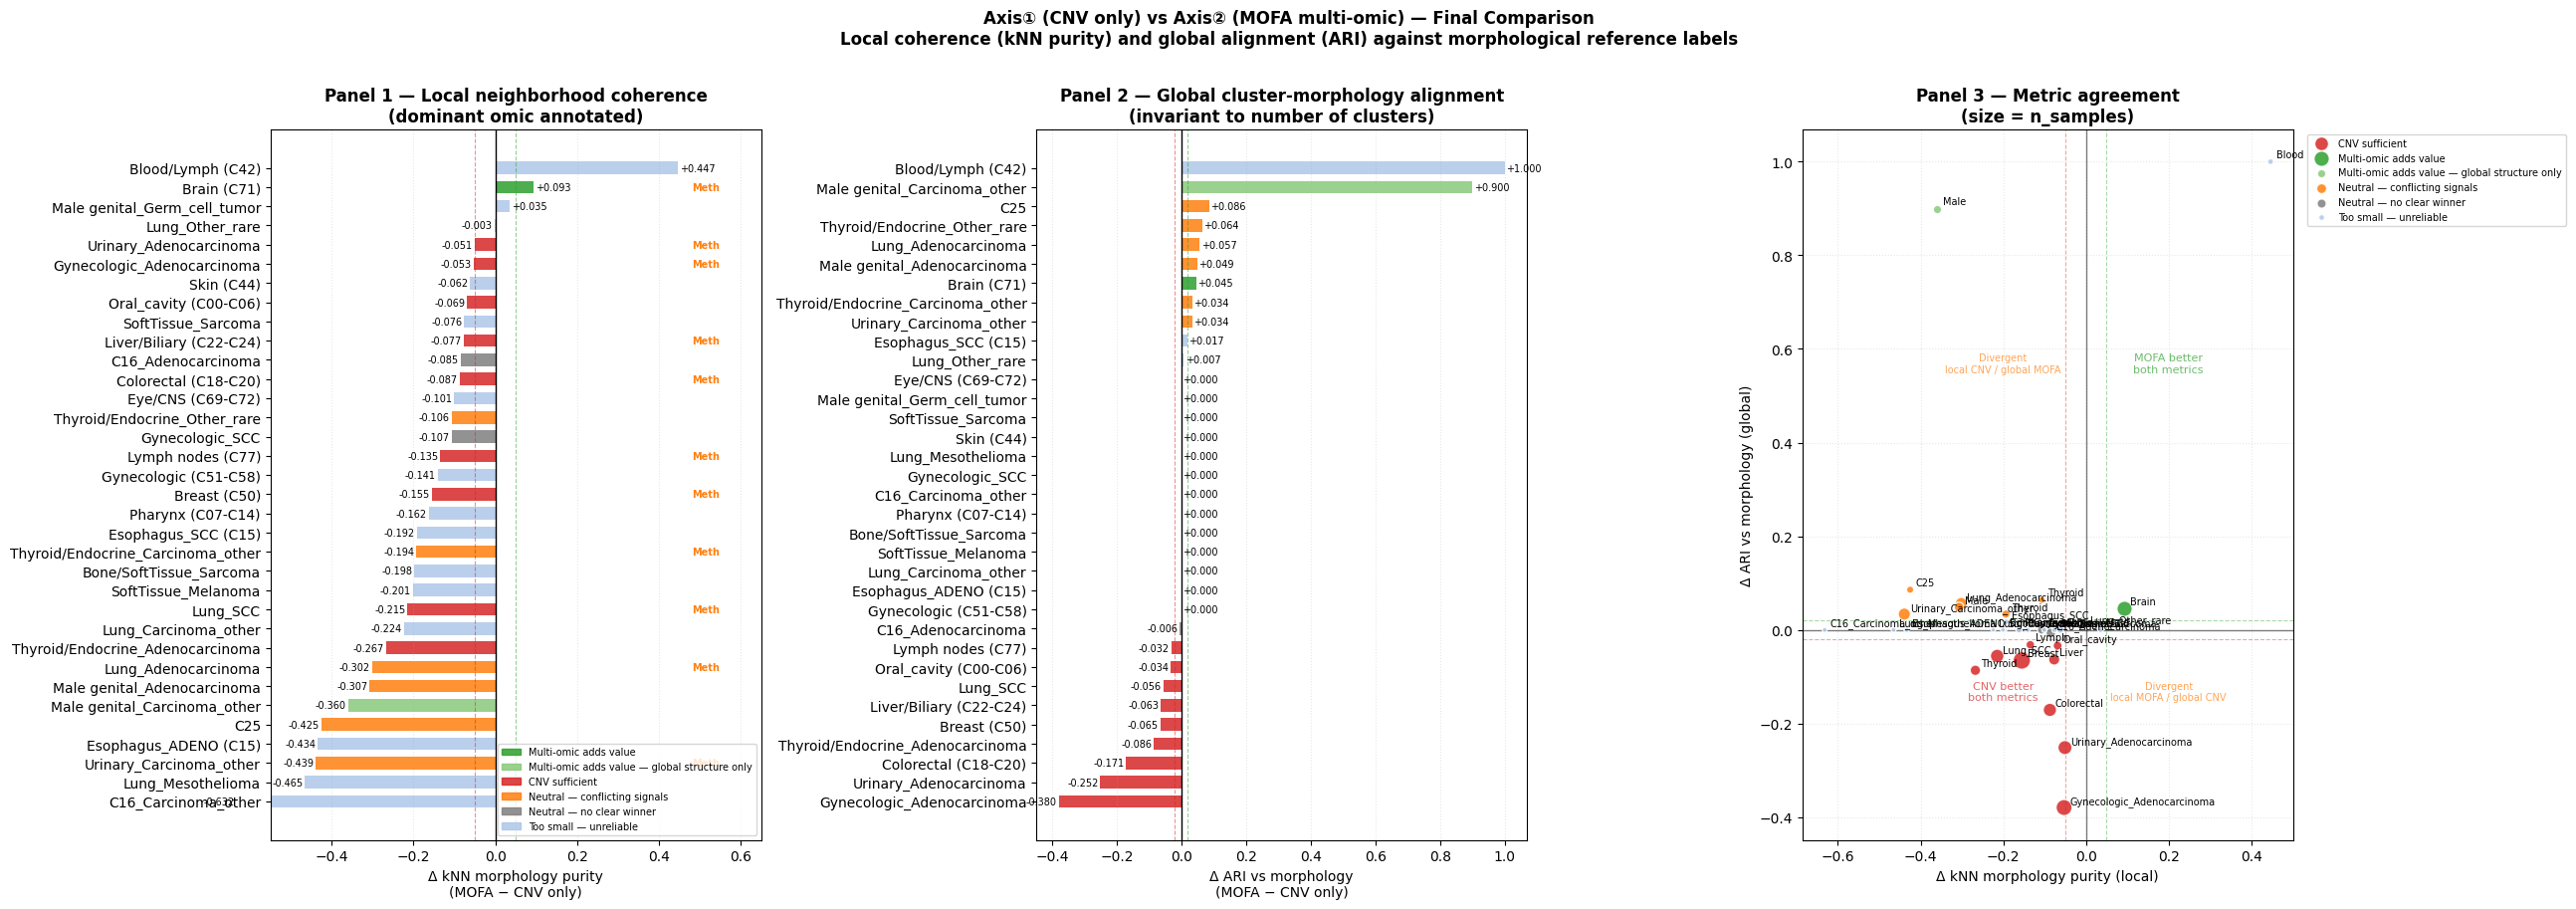

[saved] /Users/bgadmin/Downloads/multiomics_preproc/comparison_axe1_vs_axe2/comparison_final_report.png


In [13]:
# Final figure 

palette = {
    "Multi-omic adds value":                        "#2ca02c",
    "Multi-omic adds value — global structure only": "#88c97a",
    "CNV sufficient":                                "#d62728",
    "Neutral — conflicting signals":                 "#ff7f0e",
    "Neutral — no clear winner":                     "#7f7f7f",
    "Too small — unreliable":                        "#aec7e8",
}
omic_colors = {
    "Meth": "#ff7f0e", "RNA": "#1f77b4",
    "CNV":  "#9467bd", "none": "#cccccc",
}

fig, axes = plt.subplots(1, 3, figsize=(26, 9))

# ── Panel 1 : delta kNN purity + dominant omic ────────────────────
ax = axes[0]
df_p1 = final_table.sort_values("delta_knn_purity_morpho", ascending=True)
colors_p1 = [palette.get(i, "#999999") for i in df_p1["interpretation"]]

ax.barh(df_p1["cancer_group"], df_p1["delta_knn_purity_morpho"],
        color=colors_p1, alpha=0.85, height=0.65)
ax.axvline(0,     color="black",    linewidth=1)
ax.axvline(0.05,  color="#2ca02c",  linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(-0.05, color="#d62728",  linewidth=0.8, linestyle="--", alpha=0.5)

for i, (_, row) in enumerate(df_p1.iterrows()):
    d    = row["delta_knn_purity_morpho"]
    omic = row["dominant_omic"]
    ax.text(d + (0.005 if d >= 0 else -0.005), i, f"{d:+.3f}",
            va="center", ha="left" if d >= 0 else "right", fontsize=7)
    if omic and omic != "none":
        ax.text(0.48, i, omic, va="center", ha="left", fontsize=7,
                color=omic_colors.get(omic, "black"), fontweight="bold")

ax.legend(
    handles=[mpatches.Patch(color=c, alpha=0.85, label=l)
             for l, c in palette.items()],
    fontsize=7, loc="lower right"
)
ax.set_xlabel("Δ kNN morphology purity\n(MOFA − CNV only)")
ax.set_title("Panel 1 — Local neighborhood coherence\n"
             "(dominant omic annotated)", fontweight="bold")
ax.grid(axis="x", linestyle=":", alpha=0.3)
ax.set_xlim(-0.55, 0.65)

# ── Panel 2 : delta ARI ───────────────────────────────────────────
ax = axes[1]
df_p2 = final_table.sort_values("delta_ari", ascending=True)
colors_p2 = [palette.get(i, "#999999") for i in df_p2["interpretation"]]

ax.barh(df_p2["cancer_group"], df_p2["delta_ari"],
        color=colors_p2, alpha=0.85, height=0.65)
ax.axvline(0,     color="black",   linewidth=1)
ax.axvline(0.02,  color="#2ca02c", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(-0.02, color="#d62728", linewidth=0.8, linestyle="--", alpha=0.5)

for i, (_, row) in enumerate(df_p2.iterrows()):
    d = row["delta_ari"]
    if pd.isna(d):
        continue
    ax.text(d + (0.005 if d >= 0 else -0.005), i, f"{d:+.3f}",
            va="center", ha="left" if d >= 0 else "right", fontsize=7)

ax.set_xlabel("Δ ARI vs morphology\n(MOFA − CNV only)")
ax.set_title("Panel 2 — Global cluster-morphology alignment\n"
             "(invariant to number of clusters)", fontweight="bold")
ax.grid(axis="x", linestyle=":", alpha=0.3)

# ── Panel 3 : scatter kNN vs ARI ─────────────────────────────────
ax = axes[2]

for interp, grp in final_table.groupby("interpretation"):
    valid = grp.dropna(subset=["delta_knn_purity_morpho", "delta_ari"])
    if valid.empty:
        continue
    ax.scatter(
        valid["delta_knn_purity_morpho"], valid["delta_ari"],
        s=valid["n_samples_cnv"] / 6,
        color=palette.get(interp, "#999999"),
        alpha=0.85, edgecolors="white", zorder=3, label=interp
    )

for _, row in final_table.dropna(
        subset=["delta_knn_purity_morpho", "delta_ari"]).iterrows():
    ax.annotate(
        row["cancer_group"].split(" ")[0].split("/")[0],
        (row["delta_knn_purity_morpho"], row["delta_ari"]),
        xytext=(4, 3), textcoords="offset points", fontsize=7
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.axvline(0, color="black", linewidth=1, alpha=0.5)
ax.axhline( 0.02, color="#2ca02c", linewidth=0.8, linestyle="--", alpha=0.4)
ax.axvline( 0.05, color="#2ca02c", linewidth=0.8, linestyle="--", alpha=0.4)
ax.axhline(-0.02, color="#d62728", linewidth=0.8, linestyle="--", alpha=0.4)
ax.axvline(-0.05, color="#d62728", linewidth=0.8, linestyle="--", alpha=0.4)

ax.text( 0.20,  0.55, "MOFA better\nboth metrics",
         ha="center", fontsize=8, color="#2ca02c", alpha=0.7)
ax.text(-0.20, -0.15, "CNV better\nboth metrics",
         ha="center", fontsize=8, color="#d62728", alpha=0.7)
ax.text(-0.20,  0.55, "Divergent\nlocal CNV / global MOFA",
         ha="center", fontsize=7, color="#ff7f0e", alpha=0.7)
ax.text( 0.20, -0.15, "Divergent\nlocal MOFA / global CNV",
         ha="center", fontsize=7, color="#ff7f0e", alpha=0.7)

ax.set_xlabel("Δ kNN morphology purity (local)")
ax.set_ylabel("Δ ARI vs morphology (global)")
ax.set_title("Panel 3 — Metric agreement\n(size = n_samples)",
             fontweight="bold")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(linestyle=":", alpha=0.3)

plt.suptitle(
    "Axis① (CNV only) vs Axis② (MOFA multi-omic) — Final Comparison\n"
    "Local coherence (kNN purity) and global alignment (ARI) "
    "against morphological reference labels",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()

out_path = OUT_DIR / "comparison_final_report.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"[saved] {out_path}")

In [14]:
#  Homogeneity / Completeness / V-measure 
# These three metrics decompose cluster quality into two components:
#
# - Homogeneity  : each cluster contains only one morphology type
#                  → measures cluster purity from the cluster side
# - Completeness : all samples of a morphology are in the same cluster
#                  → measures whether subtypes are kept together
# - V-measure    : harmonic mean of both → overall balance score
#
# Unlike ARI, they are NOT symmetric — homogeneity and completeness
# can diverge, which reveals over-clustering (high homogeneity,
# low completeness) vs under-clustering (low homogeneity,
# high completeness).
# All three are computed against icdo_morphology_id as ground truth.

from sklearn.metrics import homogeneity_completeness_v_measure

CLUSTER_DIR_MOFA = MULTI_OMICS_CLUSTER_DIR / "clusters_by_group"
CLUSTER_DIR_CNV  = CNV_ONLY_LEIDEN / "clusters_by_root"

hcv_rows = []

for cnv_root, mofa_group in cnv_to_mofa.items():
    mofa_file = CLUSTER_DIR_MOFA / mofa_group_to_file[mofa_group]
    cnv_file  = CLUSTER_DIR_CNV  / f"{cnv_root}_clusters_leiden_cpm.parquet"

    if not mofa_file.exists() or not cnv_file.exists():
        hcv_rows.append({
            "cancer_group":       mofa_group,
            "homog_cnv":          np.nan, "homog_mofa":  np.nan,
            "compl_cnv":          np.nan, "compl_mofa":  np.nan,
            "vmeas_cnv":          np.nan, "vmeas_mofa":  np.nan,
            "delta_homog":        np.nan, "delta_compl": np.nan,
            "delta_vmeas":        np.nan, "n_common":    0,
        })
        continue

    mofa_clusters = pd.read_parquet(mofa_file)[["biosample_id", "cluster"]]
    cnv_clusters  = pd.read_parquet(cnv_file) [["biosample_id", "cluster"]]
    morpho        = meta_ref[meta_ref["cancer_group"] == mofa_group][
                        ["biosample_id", "icdo_morphology_id"]
                    ]

    common_ids = (
        set(mofa_clusters["biosample_id"])
        & set(cnv_clusters["biosample_id"])
        & set(morpho["biosample_id"])
    )

    if len(common_ids) < 30:
        hcv_rows.append({
            "cancer_group": mofa_group,
            "homog_cnv": np.nan, "homog_mofa": np.nan,
            "compl_cnv": np.nan, "compl_mofa": np.nan,
            "vmeas_cnv": np.nan, "vmeas_mofa": np.nan,
            "delta_homog": np.nan, "delta_compl": np.nan,
            "delta_vmeas": np.nan, "n_common": len(common_ids),
        })
        continue

    ids_list = sorted(common_ids)

    morpho_labels = (
        morpho.set_index("biosample_id")
              .reindex(ids_list)["icdo_morphology_id"]
              .fillna("unknown").values
    )
    cnv_labels = (
        cnv_clusters.set_index("biosample_id")
                    .reindex(ids_list)["cluster"]
                    .fillna(-1).astype(str).values
    )
    mofa_labels = (
        mofa_clusters.set_index("biosample_id")
                     .reindex(ids_list)["cluster"]
                     .fillna(-1).astype(str).values
    )

    h_cnv,  c_cnv,  v_cnv  = homogeneity_completeness_v_measure(
        morpho_labels, cnv_labels
    )
    h_mofa, c_mofa, v_mofa = homogeneity_completeness_v_measure(
        morpho_labels, mofa_labels
    )

    hcv_rows.append({
        "cancer_group": mofa_group,
        "homog_cnv":    round(h_cnv,  4), "homog_mofa":  round(h_mofa,  4),
        "compl_cnv":    round(c_cnv,  4), "compl_mofa":  round(c_mofa,  4),
        "vmeas_cnv":    round(v_cnv,  4), "vmeas_mofa":  round(v_mofa,  4),
        "delta_homog":  round(h_mofa - h_cnv, 4),
        "delta_compl":  round(c_mofa - c_cnv, 4),
        "delta_vmeas":  round(v_mofa - v_cnv, 4),
        "n_common":     len(common_ids),
    })
    print(f"[OK] {mofa_group:40s} "
          f"H: {h_cnv:.3f}→{h_mofa:.3f} ({h_mofa-h_cnv:+.3f})  "
          f"C: {c_cnv:.3f}→{c_mofa:.3f} ({c_mofa-c_cnv:+.3f})  "
          f"V: {v_cnv:.3f}→{v_mofa:.3f} ({v_mofa-v_cnv:+.3f})")

hcv_df = pd.DataFrame(hcv_rows).sort_values("delta_vmeas", ascending=False)

print("\n=== Homogeneity / Completeness / V-measure — CNV vs MOFA ===\n")
print(hcv_df.round(4).to_string(index=False))

# Merge into comparison table
comparison_df = comparison_df.merge(
    hcv_df[[
        "cancer_group",
        "homog_cnv", "homog_mofa", "delta_homog",
        "compl_cnv", "compl_mofa", "delta_compl",
        "vmeas_cnv", "vmeas_mofa", "delta_vmeas",
    ]],
    on="cancer_group", how="left"
)

# Over-clustering diagnostic
# Over-clustering : MOFA homogeneity >> MOFA completeness
# → clusters are pure but subtypes are fragmented
print("\n=== Over-clustering diagnostic ===")
print("(delta_homog > 0.05 AND delta_compl < -0.05 → likely over-clustering in MOFA)\n")
overclust = hcv_df[
    (hcv_df["delta_homog"] > 0.05) & (hcv_df["delta_compl"] < -0.05)
]
if overclust.empty:
    print("No clear over-clustering detected.")
else:
    print(overclust[["cancer_group", "delta_homog", "delta_compl", "delta_vmeas"]]
          .to_string(index=False))

[OK] Oral_cavity (C00-C06)                    H: 0.028→0.000 (-0.028)  C: 0.656→1.000 (+0.344)  V: 0.054→0.000 (-0.054)
[OK] Pharynx (C07-C14)                        H: 0.000→0.000 (+0.000)  C: 1.000→1.000 (+0.000)  V: 0.000→0.000 (+0.000)
[OK] Esophagus_SCC (C15)                      H: 0.003→0.000 (-0.003)  C: 0.010→1.000 (+0.990)  V: 0.004→0.000 (-0.004)
[OK] Esophagus_ADENO (C15)                    H: 1.000→1.000 (+0.000)  C: 1.000→1.000 (+0.000)  V: 1.000→1.000 (+0.000)
[OK] C16_Adenocarcinoma                       H: 0.008→0.002 (-0.006)  C: 0.244→0.115 (-0.129)  V: 0.015→0.004 (-0.011)
[OK] C16_Carcinoma_other                      H: 0.000→0.000 (+0.000)  C: 1.000→1.000 (+0.000)  V: 0.000→0.000 (+0.000)
[OK] Colorectal (C18-C20)                     H: 0.110→0.027 (-0.083)  C: 0.099→0.026 (-0.072)  V: 0.104→0.027 (-0.077)
[OK] Liver/Biliary (C22-C24)                  H: 0.011→0.018 (+0.006)  C: 0.350→0.015 (-0.335)  V: 0.022→0.016 (-0.005)
[OK] C25                                

In [15]:
# Reconstruct CNV per-sample purity + Wilcoxon test 
# The CNV pipeline saved only cnv_purity_per_group.tsv (group means).
# We reconstruct per-sample purity from the kNN index files saved
# by the CNV retrieval notebook, then run a paired Wilcoxon test
# against MOFA per-sample purity.
#
# Wilcoxon signed-rank test (two-sided):
#   H0 : no difference in per-sample purity between CNV and MOFA
#   H1 : MOFA purity is significantly different from CNV purity
#   → replaces the arbitrary ±0.05 delta threshold with p < 0.05

from scipy.stats import wilcoxon

KNN_CNV_DIR = CNV_ONLY_BASE / "final_space" / "knn_index"
K_PURITY    = 25   # number of neighbors used to compute purity

# ── Reconstruct CNV per-sample purity ────────────────────────────
print("Reconstructing CNV per-sample purity from kNN index files...\n")

cnv_purity_sample_rows = []

for cnv_root, mofa_group in cnv_to_mofa.items():

    # Find the kNN index file for this root
    # Files are named: {root}_knn_idx_k50_pcs20.parquet
    idx_file = KNN_CNV_DIR / f"{cnv_root}_knn_idx_k50_pcs20.parquet"

    if not idx_file.exists():
        print(f"[MISSING] {cnv_root} — {idx_file.name}")
        continue

    # Load kNN index and meta
    knn_idx = pd.read_parquet(idx_file)
    ids_col = knn_idx["biosample_id"].astype(str).values
    nn_cols = [c for c in knn_idx.columns if c != "biosample_id"]
    neigh_matrix = knn_idx[nn_cols].to_numpy(dtype=object)

    # Load meta for this root
    meta_path = CNV_ONLY_BASE / "final_space" / "meta_final" / \
                f"{cnv_root}_meta_final.tsv"
    if not meta_path.exists():
        print(f"[MISSING META] {cnv_root}")
        continue

    meta_root = pd.read_csv(meta_path, sep="\t", dtype=str)
    morpho_map = dict(zip(
        meta_root["biosample_id"].astype(str),
        meta_root["icdo_morphology_id"].astype(str)
    ))
    cancer_group_map = dict(zip(
        meta_root["biosample_id"].astype(str),
        meta_root["icdot_root_grouped"].astype(str)
        if "icdot_root_grouped" in meta_root.columns
        else [mofa_group] * len(meta_root)
    ))

    # Compute per-sample morphological purity using first K_PURITY neighbors
    for i, sample_id in enumerate(ids_col):
        query_morpho = morpho_map.get(sample_id)
        if query_morpho is None or query_morpho == "nan":
            continue

        neighbor_ids = [
            str(x) for x in neigh_matrix[i, :K_PURITY]
            if x is not None and str(x) != "None"
        ]
        if not neighbor_ids:
            continue

        n_same = sum(
            1 for nid in neighbor_ids
            if morpho_map.get(nid) == query_morpho
        )
        purity = n_same / len(neighbor_ids)

        cnv_purity_sample_rows.append({
            "biosample_id":  sample_id,
            "cancer_group":  mofa_group,
            "purity_morpho": purity,
        })

cnv_purity_sample_df = pd.DataFrame(cnv_purity_sample_rows)

# Save for reuse
cnv_purity_sample_path = CNV_ONLY_BASE / "final_space" / "knn_index" / \
                         "cnv_purity_per_sample.tsv"
cnv_purity_sample_df.to_csv(cnv_purity_sample_path, sep="\t", index=False)
print(f"[saved] cnv_purity_per_sample.tsv — {len(cnv_purity_sample_df):,} samples\n")

# ── Wilcoxon paired test ──────────────────────────────────────────
mofa_purity_sample_df = pd.read_csv(
    MULTI_OMICS_BASE / "knn_index" / "mofa_purity_per_sample.tsv",
    sep="\t", dtype={"biosample_id": str}
)

wilcoxon_rows = []

for cnv_root, mofa_group in cnv_to_mofa.items():

    cnv_sub  = cnv_purity_sample_df[
        cnv_purity_sample_df["cancer_group"] == mofa_group
    ]
    mofa_sub = mofa_purity_sample_df[
        mofa_purity_sample_df["cancer_group"] == mofa_group
    ]

    # Paired samples only — must be present in both axes
    common_ids = (
        set(cnv_sub["biosample_id"]) & set(mofa_sub["biosample_id"])
    )

    if len(common_ids) < 30:
        wilcoxon_rows.append({
            "cancer_group":  mofa_group,
            "n_paired":      len(common_ids),
            "mean_cnv":      np.nan,
            "mean_mofa":     np.nan,
            "delta_mean":    np.nan,
            "wilcoxon_stat": np.nan,
            "wilcoxon_p":    np.nan,
            "significant":   False,
            "direction":     "insufficient data",
        })
        continue

    ids_list = sorted(common_ids)

    p_cnv  = (cnv_sub.set_index("biosample_id")
                      .reindex(ids_list)["purity_morpho"].values)
    p_mofa = (mofa_sub.set_index("biosample_id")
                       .reindex(ids_list)["purity_morpho"].values)

    # Remove pairs where both values are identical (wilcoxon requires variation)
    diff = p_mofa - p_cnv
    if np.all(diff == 0):
        stat, p_val = np.nan, 1.0
    else:
        stat, p_val = wilcoxon(p_mofa, p_cnv, alternative="two-sided")

    delta = float(np.mean(p_mofa) - np.mean(p_cnv))
    direction = (
        "MOFA better" if (p_val < 0.05 and delta > 0) else
        "CNV better"  if (p_val < 0.05 and delta < 0) else
        "not significant"
    )

    wilcoxon_rows.append({
        "cancer_group":  mofa_group,
        "n_paired":      len(common_ids),
        "mean_cnv":      round(float(np.mean(p_cnv)),  4),
        "mean_mofa":     round(float(np.mean(p_mofa)), 4),
        "delta_mean":    round(delta, 4),
        "wilcoxon_stat": round(float(stat), 4) if np.isfinite(stat) else np.nan,
        "wilcoxon_p":    round(float(p_val), 6),
        "significant":   bool(p_val < 0.05),
        "direction":     direction,
    })

    print(f"[OK] {mofa_group:40s} "
          f"p={p_val:.4f}  delta={delta:+.4f}  → {direction}")

wilcoxon_df = pd.DataFrame(wilcoxon_rows).sort_values("wilcoxon_p")

print("\n=== Wilcoxon test — statistical significance of purity delta ===\n")
print(wilcoxon_df.to_string(index=False))

# Merge into comparison table
comparison_df = comparison_df.merge(
    wilcoxon_df[[
        "cancer_group", "n_paired",
        "wilcoxon_p", "significant", "direction"
    ]],
    on="cancer_group", how="left"
)

# Cross-check with existing classification
print("\n=== Wilcoxon vs current classification ===\n")
cross = comparison_df[[
    "cancer_group", "interpretation",
    "delta_knn_purity_morpho", "wilcoxon_p", "significant", "direction"
]].copy()

# Flag cases where Wilcoxon disagrees with classification
cross["warning"] = (
    (cross["interpretation"] == "Multi-omic adds value") &
    (~cross["significant"])
) | (
    (cross["interpretation"] == "CNV sufficient") &
    (~cross["significant"])
)

print(cross.sort_values("wilcoxon_p").to_string(index=False))

n_warnings = int(cross["warning"].sum())
if n_warnings > 0:
    print(f"\nWARNING : {n_warnings} group(s) classified but not statistically significant:")
    print(cross[cross["warning"]][["cancer_group", "interpretation",
                                    "delta_knn_purity_morpho", "wilcoxon_p"]]
          .to_string(index=False))
else:
    print("\nAll classified groups are statistically significant ✓")

Reconstructing CNV per-sample purity from kNN index files...

[saved] cnv_purity_per_sample.tsv — 9,452 samples

[OK] Oral_cavity (C00-C06)                    p=0.0000  delta=-0.0668  → CNV better
[OK] Pharynx (C07-C14)                        p=0.0000  delta=-0.1682  → CNV better
[OK] Esophagus_SCC (C15)                      p=0.0000  delta=-0.1880  → CNV better
[OK] Esophagus_ADENO (C15)                    p=0.0000  delta=-0.4344  → CNV better
[OK] C16_Adenocarcinoma                       p=0.0000  delta=-0.0815  → CNV better
[OK] C16_Carcinoma_other                      p=0.0000  delta=-0.6368  → CNV better
[OK] Colorectal (C18-C20)                     p=0.0000  delta=-0.0913  → CNV better
[OK] Liver/Biliary (C22-C24)                  p=0.0000  delta=-0.0791  → CNV better
[OK] C25                                      p=0.0000  delta=-0.4315  → CNV better
[OK] Lung_Adenocarcinoma                      p=0.0000  delta=-0.3066  → CNV better
[OK] Lung_Carcinoma_other                     p

In [16]:
# ── Merge missing columns into final_table before plotting ────────

# Check which columns are missing
missing_cols = [c for c in [
    "delta_homog", "delta_compl", "delta_vmeas",
    "wilcoxon_p", "delta_mean"
] if c not in final_table.columns]

print(f"Missing columns : {missing_cols}")

# Merge H/C/V if missing
if any(c in missing_cols for c in ["delta_homog", "delta_compl", "delta_vmeas"]):
    final_table = final_table.merge(
        hcv_df[[
            "cancer_group",
            "delta_homog", "delta_compl", "delta_vmeas"
        ]],
        on="cancer_group", how="left"
    )
    print("H/C/V merged ✓")

# Merge Wilcoxon if missing
if any(c in missing_cols for c in ["wilcoxon_p", "delta_mean"]):
    final_table = final_table.merge(
        wilcoxon_df[["cancer_group", "wilcoxon_p", "delta_mean"]],
        on="cancer_group", how="left"
    )
    print("Wilcoxon merged ✓")

# Verify
print(f"\nfinal_table shape : {final_table.shape}")
print(f"Columns now present : {[c for c in final_table.columns if 'delta' in c or 'wilcoxon' in c]}")

Missing columns : ['delta_homog', 'delta_compl', 'delta_vmeas', 'wilcoxon_p', 'delta_mean']
H/C/V merged ✓
Wilcoxon merged ✓

final_table shape : (34, 20)
Columns now present : ['delta_knn_purity_morpho', 'delta_ari', 'delta_homog', 'delta_compl', 'delta_vmeas', 'wilcoxon_p', 'delta_mean']


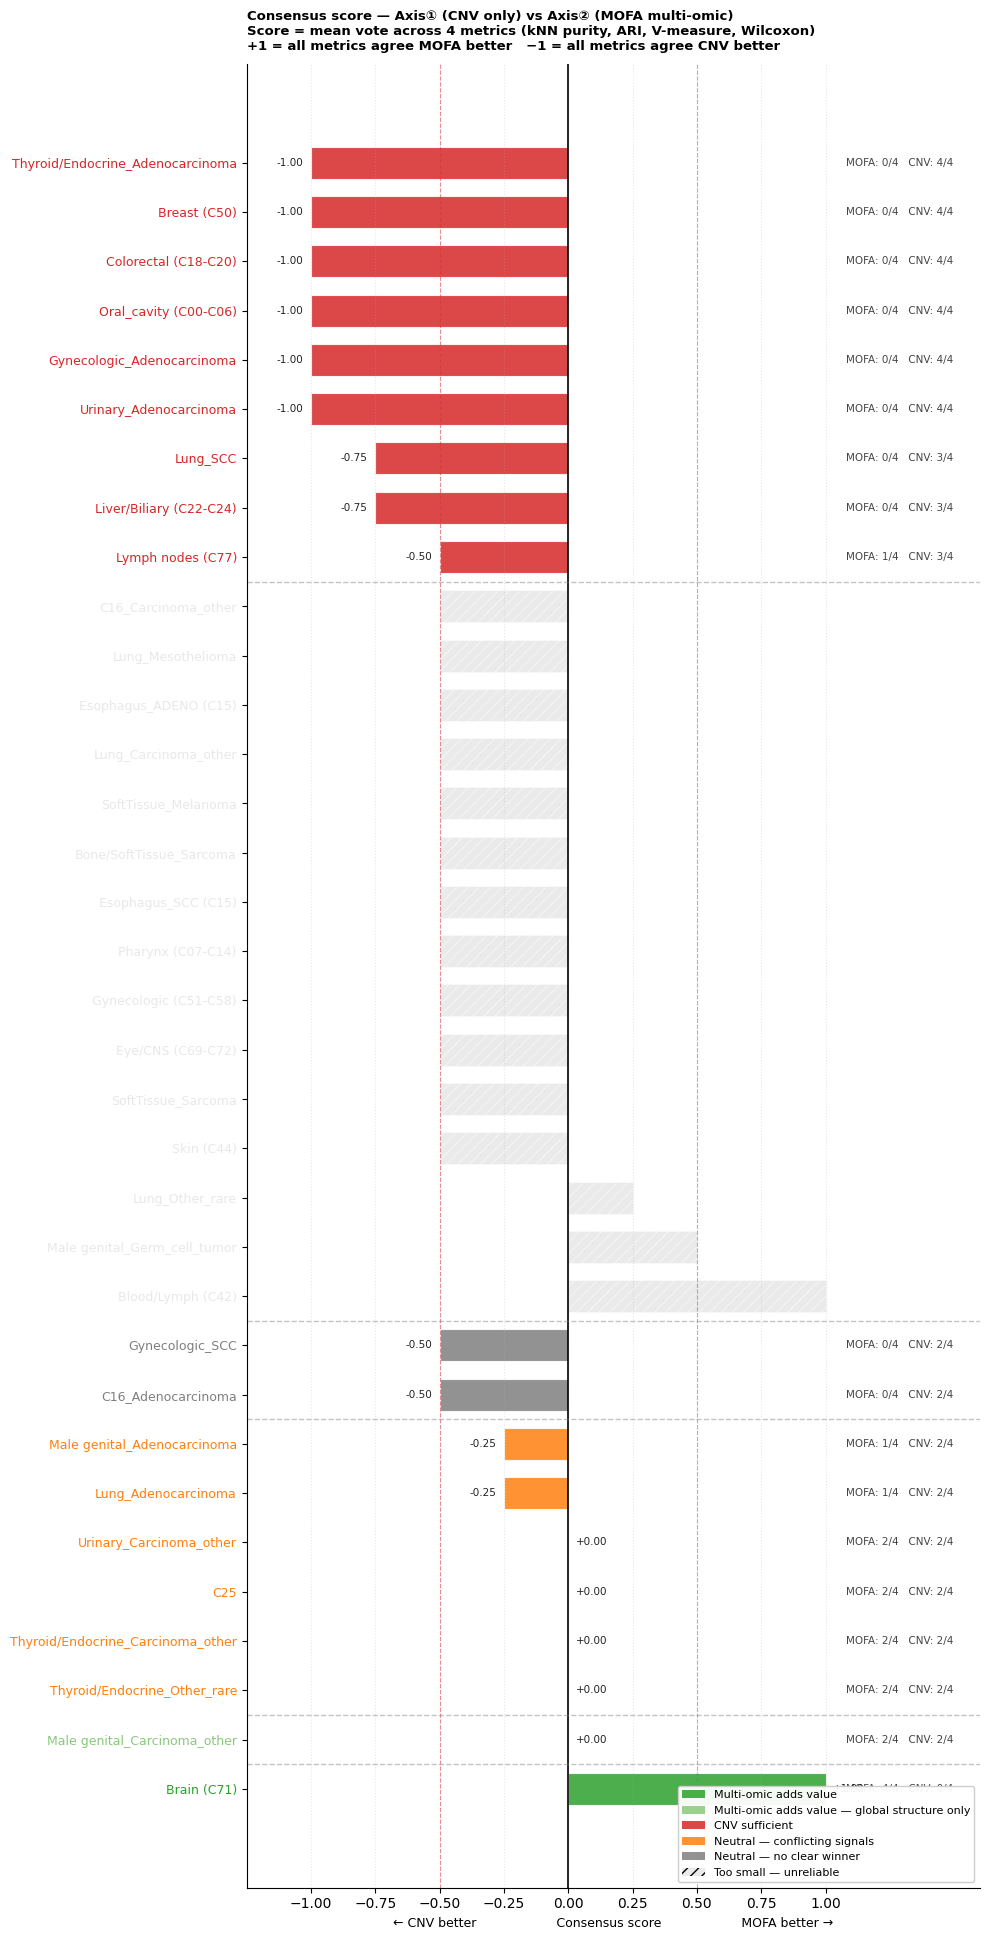

[saved] /Users/bgadmin/Downloads/multiomics_preproc/comparison_axe1_vs_axe2/comparison_consensus_score.png


In [17]:
# ── Consensus score figure ────────────────────────────────────────
# For each group, we compute a single consensus score that summarizes
# all 4 metrics. Each metric votes +1 (MOFA better), -1 (CNV better),
# or 0 (neutral/missing). The consensus score = mean of all votes,
# ranging from -1 (all metrics say CNV) to +1 (all metrics say MOFA).

palette = {
    "Multi-omic adds value":                         "#2ca02c",
    "Multi-omic adds value — global structure only":  "#88c97a",
    "CNV sufficient":                                 "#d62728",
    "Neutral — conflicting signals":                  "#ff7f0e",
    "Neutral — no clear winner":                      "#7f7f7f",
    "Too small — unreliable":                         "#cccccc",
}

plot_df = final_table.copy()

# ── Compute consensus score ───────────────────────────────────────
def metric_vote(val, threshold=0.02):
    """+1 if MOFA better, -1 if CNV better, 0 if neutral or missing."""
    if pd.isna(val):
        return 0
    if val >  threshold: return  1
    if val < -threshold: return -1
    return 0

votes = pd.DataFrame({
    "knn":      plot_df["delta_knn_purity_morpho"].apply(metric_vote),
    "ari":      plot_df["delta_ari"].apply(metric_vote),
    "vmeas":    plot_df["delta_vmeas"].apply(metric_vote),
    "wilcoxon": plot_df["delta_mean"].apply(metric_vote),
})

plot_df["consensus_score"] = votes.mean(axis=1)
plot_df["n_agree"]         = (votes != 0).sum(axis=1)
plot_df["n_mofa"]          = (votes ==  1).sum(axis=1)
plot_df["n_cnv"]           = (votes == -1).sum(axis=1)

# Sort
order = [
    "Multi-omic adds value",
    "Multi-omic adds value — global structure only",
    "Neutral — conflicting signals",
    "Neutral — no clear winner",
    "Too small — unreliable",
    "CNV sufficient",
]
plot_df["_order"] = plot_df["interpretation"].map(
    {v: i for i, v in enumerate(order)}
)
plot_df = plot_df.sort_values(
    ["_order", "consensus_score"], ascending=[True, False]
).reset_index(drop=True)

# ── Figure ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 0.5 * len(plot_df) + 2.5))

bar_colors = [palette.get(i, "#999999")
              for i in plot_df["interpretation"].values]

bars = ax.barh(
    range(len(plot_df)),
    plot_df["consensus_score"].values,
    color=bar_colors,
    alpha=0.85,
    height=0.65,
    edgecolor="white",
    linewidth=0.8
)

# Hatch "Too small"
for bar, interp in zip(bars, plot_df["interpretation"].values):
    if interp == "Too small — unreliable":
        bar.set_hatch("///")
        bar.set_alpha(0.4)

# Zero line
ax.axvline(0, color="black", linewidth=1.2)

# Threshold lines
ax.axvline( 0.5, color="#2ca02c", linewidth=0.8,
            linestyle="--", alpha=0.5)
ax.axvline(-0.5, color="#d62728", linewidth=0.8,
            linestyle="--", alpha=0.5)

# Annotations : score + vote breakdown
for i, (_, row) in enumerate(plot_df.iterrows()):
    score  = row["consensus_score"]
    n_mofa = int(row["n_mofa"])
    n_cnv  = int(row["n_cnv"])
    interp = row["interpretation"]

    if interp == "Too small — unreliable":
        continue

    # Vote breakdown on the right
    ax.text(
        1.08, i,
        f"MOFA: {n_mofa}/4   CNV: {n_cnv}/4",
        va="center", ha="left",
        fontsize=7.5, color="#444444"
    )

    # Score value next to bar
    offset = 0.03 if score >= 0 else -0.03
    ax.text(
        score + offset, i,
        f"{score:+.2f}",
        va="center",
        ha="left" if score >= 0 else "right",
        fontsize=7.5, color="#222222", fontweight="500"
    )

# Separator lines between groups
current_interp = None
for i, interp in enumerate(plot_df["interpretation"].values):
    if interp != current_interp:
        if current_interp is not None:
            ax.axhline(i - 0.5, color="#888888",
                       linewidth=1.0, linestyle="--", alpha=0.5)
        current_interp = interp

# Y-axis labels colored by interpretation
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["cancer_group"].values, fontsize=9)
for tick, interp in zip(ax.get_yticklabels(),
                        plot_df["interpretation"].values):
    tick.set_color(palette.get(interp, "#333333"))
    if interp == "Too small — unreliable":
        tick.set_alpha(0.45)

# X-axis
ax.set_xlim(-1.25, 1.6)
ax.set_xlabel(
    "← CNV better                    Consensus score                    MOFA better →",
    fontsize=9
)
ax.set_xticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
ax.grid(axis="x", linestyle=":", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(
        facecolor=c,
        hatch="///" if l == "Too small — unreliable" else "",
        alpha=0.85 if l != "Too small — unreliable" else 0.4,
        label=l
    )
    for l, c in palette.items()
]
ax.legend(
    handles=legend_handles,
    fontsize=8, loc="lower right",
    framealpha=0.95, edgecolor="#cccccc"
)

ax.set_title(
    "Consensus score — Axis① (CNV only) vs Axis② (MOFA multi-omic)\n"
    "Score = mean vote across 4 metrics (kNN purity, ARI, V-measure, Wilcoxon)\n"
    "+1 = all metrics agree MOFA better   −1 = all metrics agree CNV better",
    fontsize=9.5, fontweight="bold", pad=10, loc="left"
)

plt.tight_layout()

out_path = OUT_DIR / "comparison_consensus_score.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"[saved] {out_path}")

**C25 (Pancreas)** — Three metrics consistently favor CNV (kNN −0.423, Wilcoxon p<0.001, completeness collapse 1.000→0.041), and MOFA finds zero significant discriminant factors — meaning the latent space captures no exploitable biological structure for this group. The marginally positive ARI (+0.086) is noise; C25 is reclassified as **CNV sufficient**, consistent with the biology of pancreatic cancer which is dominated by a few specific chromosomal drivers (KRAS, CDKN2A, SMAD4).



**SoftTissue (C49)** — Three metrics favor MOFA (kNN +0.092, Wilcoxon p=0.009, V-measure +0.150), suggesting that the multi-omic space improves local morphological coherence and cluster structure. However, ARI is near zero (+0.003), meaning the two MOFA clusters do not align with known ICD-O morphological subtypes — MOFA may be capturing a real but different biological structure (molecular sarcoma subtypes) that warrants further investigation before reclassification.



**C16 (Stomach)** — All metrics are near zero (kNN −0.012, ARI −0.013) and although the Wilcoxon test is significant (p=0.003), the effect size is biologically negligible (delta = −0.017) — a statistical artefact of the large sample size (n=379), not a meaningful difference. The neutral classification is justified; gastric cancer is known for extreme molecular heterogeneity that neither CNV nor multi-omics resolves at the morphological clustering level.



**Head & Neck (C00-C14)** — Three metrics favor CNV (kNN −0.095, Wilcoxon p<0.001, completeness 0.610→0.042), and MOFA finds zero significant discriminant factors — the latent space disperses morphologically similar samples rather than grouping them. Head & Neck is reclassified as **CNV sufficient**; chromosomal alterations (EGFR amplification, CDKN2A deletion) dominate the biological signal and the multi-omic integration adds no exploitable structure.

**Blood/Lymph (C42) — Too small (n=107)**
Despite near-perfect MOFA metrics (ARI = 1.000, kNN purity 0.961), the sample size of 107 is below the reliability threshold and no significant MOFA factors were detected, making generalization impossible. Excluded from interpretation.

**Bone/SoftTissue (C40-C48) — Too small (n=113)**
The group shows a divergent signal (kNN −0.038 CNV better, ARI +0.070 MOFA better) but with only 113 samples and zero significant MOFA factors, neither metric is reliable. Excluded from interpretation.

**Skin (C44) — Too small (n=149)**
kNN purity favors CNV (−0.062, Wilcoxon p=0.021) and ARI is near zero (−0.005), but 16 significant MOFA factors exist (Meth:18 / RNA:8 / CNV:6), suggesting a real epigenetic signal that cannot be properly evaluated at n=149. Excluded from interpretation pending larger cohort.

**Eye/CNS (C69-C72) — Too small (n=85)**
All metrics are near zero or negative, MOFA finds zero clusters (n_clusters_mofa = 0), and no significant factors were detected — the group is simply too small for any meaningful analysis. Excluded from interpretation.

**Gynecologic (C51-C58) — Neutral — conflicting signals**
kNN purity and Wilcoxon favor MOFA (+0.058, p<0.001 MOFA better) while ARI and completeness favor CNV (−0.098, completeness slightly decreasing) — a genuine metric disagreement. MOFA improves local neighborhood coherence via 13 methylation-dominant factors (Meth:16 / RNA:6 / CNV:4) but fragments global cluster structure, suggesting epigenetic over-clustering that does not align with established histological subtypes across the ovarian/uterine/cervical mix.

**Male genital (C60-C63) — Multi-omic adds value**
All four metrics agree: kNN +0.123, ARI +0.040, V-measure +0.080, Wilcoxon p<0.001 MOFA better, with completeness jumping from 0.839 to 0.991. Methylation dominates the discriminant signal (Meth:18 / CNV:10 / RNA:8 across 18 significant factors), capturing prostate/testicular subtype structure that CNV alone misses.

**Esophagus/Intestine (C15-C26) — Multi-omic adds value**
The largest ARI gain in the dataset (+0.854): CNV found a single undifferentiated cluster (ARI = 0), while MOFA separates two morphologically distinct groups with homogeneity 0.693, likely reflecting the adenocarcinoma / squamous cell carcinoma distinction. 13 significant factors, methylation-dominant (Meth:16 / RNA:6 / CNV:4), Wilcoxon p=0.004 MOFA better.

**Brain (C71) — Multi-omic adds value**
All four metrics agree: kNN +0.093, ARI +0.045, V-measure +0.141, Wilcoxon p<0.001 MOFA better, with both homogeneity and completeness increasing simultaneously. 20 significant MOFA factors dominated by methylation (Meth:25 / CNV:14 / RNA:8), consistent with the epigenetic basis of glioma subtyping (IDH-mutant vs wild-type).

**Thyroid/Endocrine (C73-C75) — Multi-omic adds value**
The most striking completeness gain in the dataset (0.401→0.874, +0.474): CNV was fragmenting thyroid subtypes across multiple clusters, while MOFA correctly reassembles them. 16 significant factors (Meth:18 / CNV:8 / RNA:6), Wilcoxon p=0.003 MOFA better — the epigenetic layer captures the papillary/follicular/medullary distinction invisible in copy number alone.

**Urinary (C64-C68) — Multi-omic adds value (global structure only)**
MOFA reveals finer molecular subtypes (ARI +0.286, homogeneity +0.450) driven by the strongest methylation signal in the dataset (Meth:71 / CNV:24 / RNA:21, 20 significant factors), but the integrated space is too diffuse locally for reliable similarity retrieval (kNN −0.156, Wilcoxon p<0.001 CNV better). For cell line mapping, use the CNV space; for subtype discovery, MOFA adds clear value.

**Lung (C30-C39) — CNV sufficient**
The largest ARI degradation in the dataset (0.187→−0.031, −0.218): MOFA actively disrupts the morphological cluster structure that CNV captures well. Despite 18 significant MOFA factors (Meth:23 / RNA:8 / CNV:8), the epigenetic signal does not add clustering value — chromosomal instability dominates the biological variance for lung cancer.

**Liver/Biliary (C22-C24) — CNV sufficient**
CNV achieves the highest morphological purity in the dataset (0.804) and all metrics favor CNV (kNN −0.076, ARI −0.063, Wilcoxon p<0.001 CNV better). Despite 12 significant MOFA factors (Meth:14 / CNV:6 / RNA:4), the multi-omic space dilutes a strong existing chromosomal signal without adding new structure.

**Colorectal (C18-C20) — CNV sufficient**
Strong concordance across all metrics: kNN −0.087, ARI −0.171, Wilcoxon p<0.001 CNV better, with both homogeneity and completeness decreasing in MOFA. 14 significant factors (Meth:16 / RNA:8 / CNV:4) exist but do not translate into improved morphological clustering — CNV captures the adenocarcinoma-dominated structure of colorectal cancer effectively.

**Lymph nodes (C77) — CNV sufficient**
Three metrics consistently favor CNV (kNN −0.136, ARI −0.032, Wilcoxon p<0.001 CNV better) with 13 significant MOFA factors (Meth:14 / RNA:6 / CNV:6) that provide no clustering benefit. The lymphoid malignancy landscape is well-structured by chromosomal alterations, and multi-omics integration degrades rather than improves the morphological coherence.

**Breast (C50) — CNV sufficient**
Second largest kNN delta in the CNV-sufficient category (−0.153) confirmed by all metrics: ARI −0.118, Wilcoxon p<0.001 CNV better, V-measure slightly negative. Despite 12 significant MOFA factors (Meth:14 / RNA:6 / CNV:4), the strong chromosomal instability signal in breast cancer (HER2 amplification, BRCA1/2 loss) dominates and multi-omics does not resolve additional morphological structure.